<a href="https://colab.research.google.com/github/gopikaramalingam31-ops/Gopika-spotify-minor-project/blob/main/Minor_project_spotify_songs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from google.colab import files
Uploaded=files.upload()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

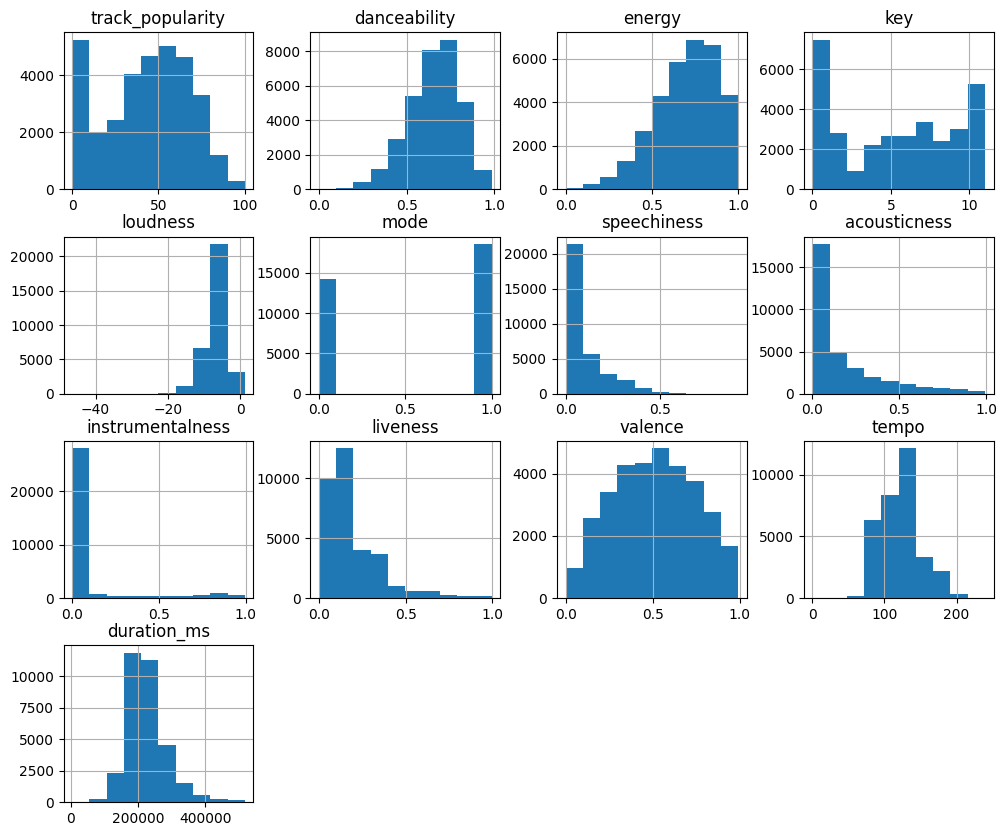

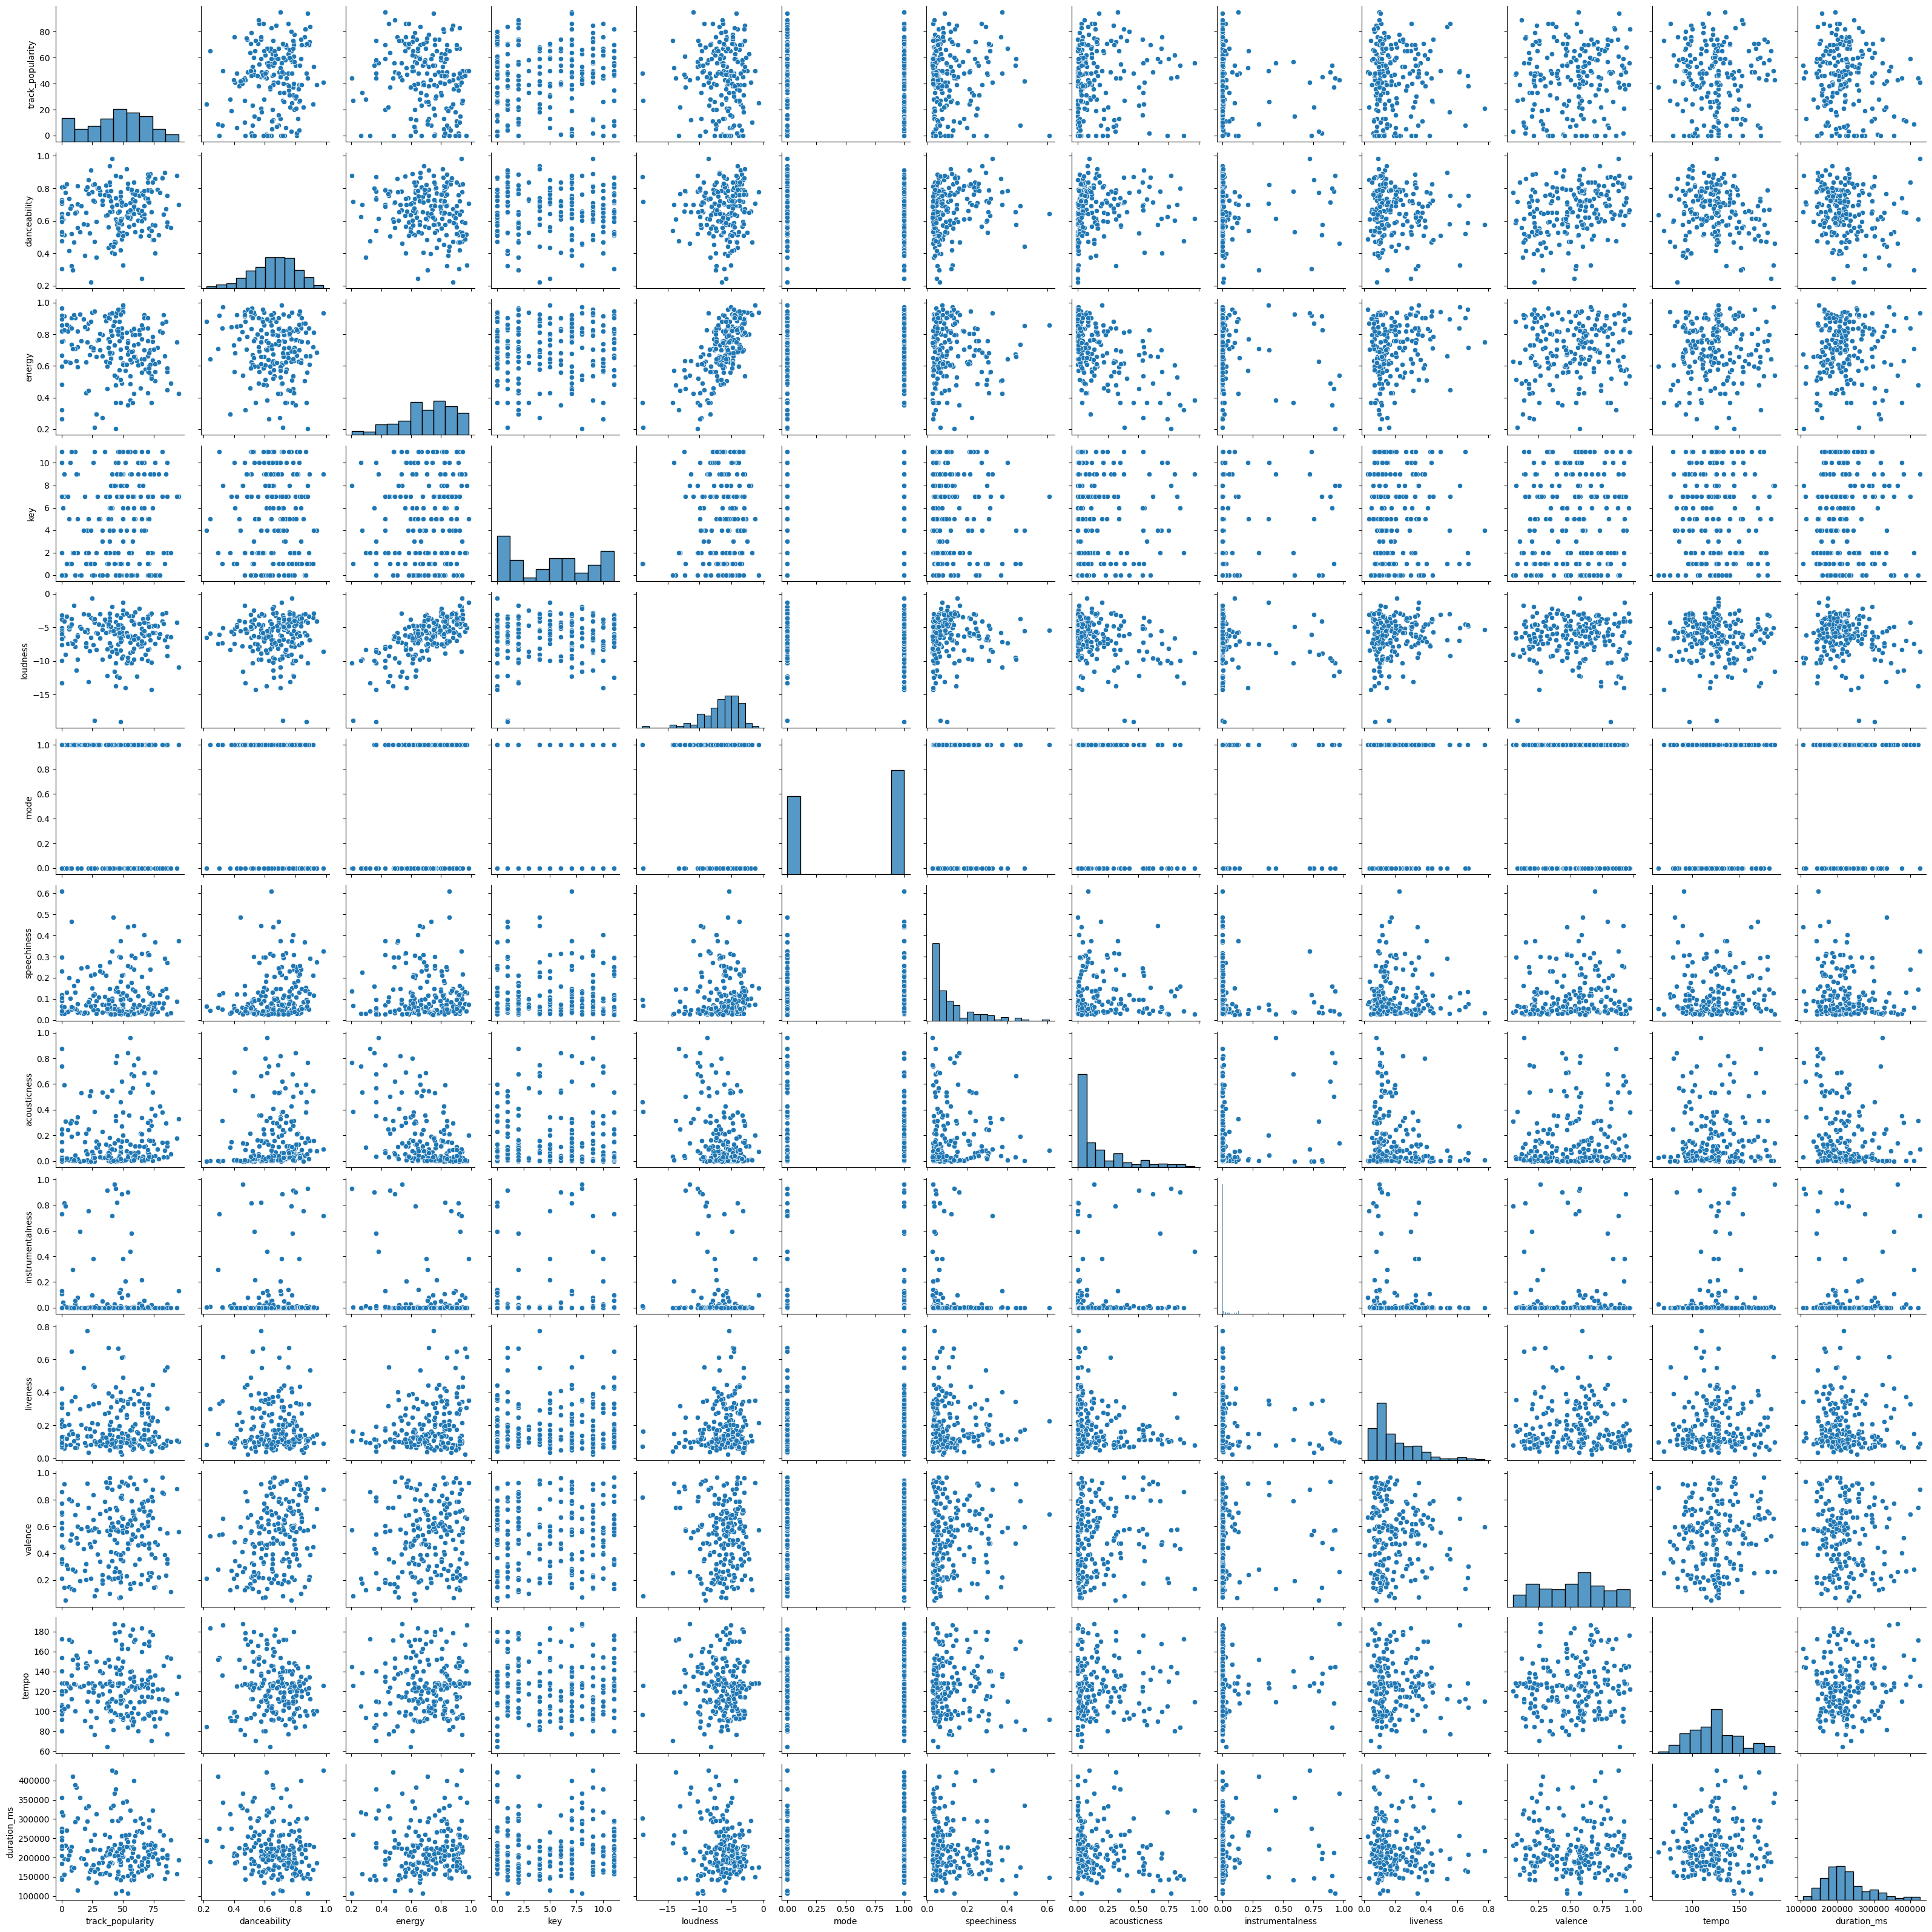

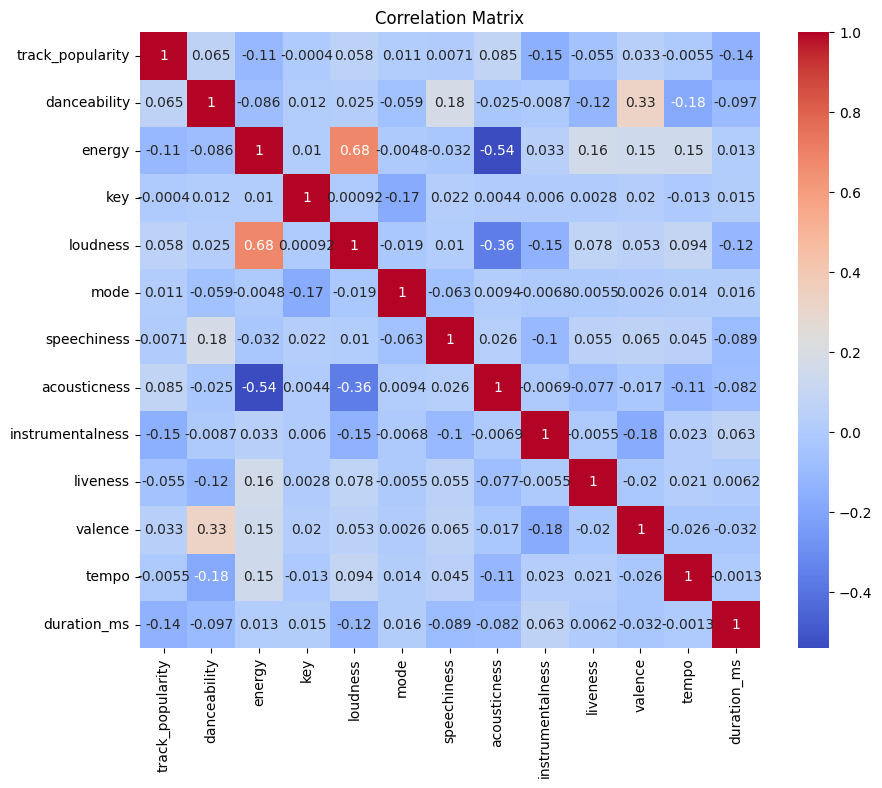

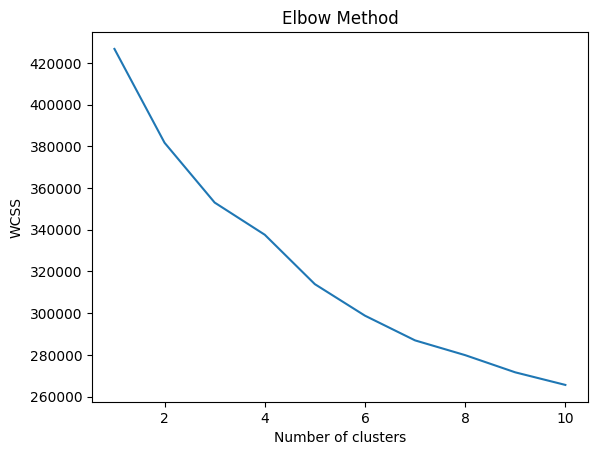

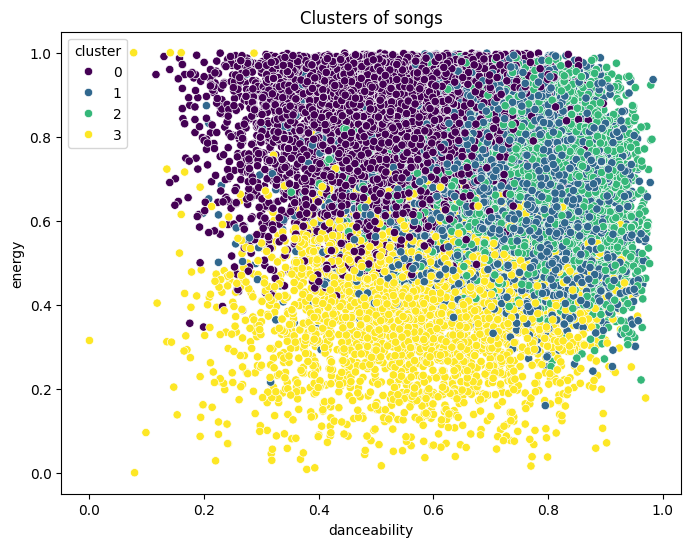

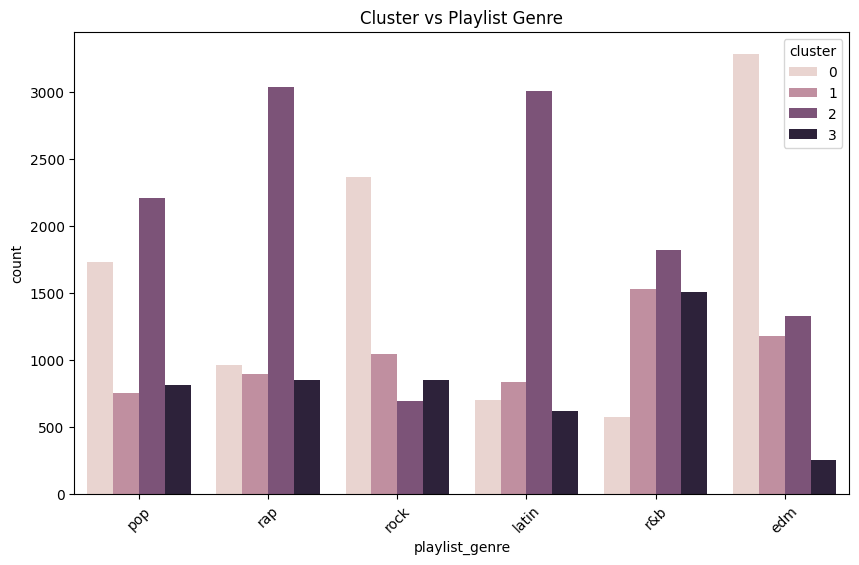

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


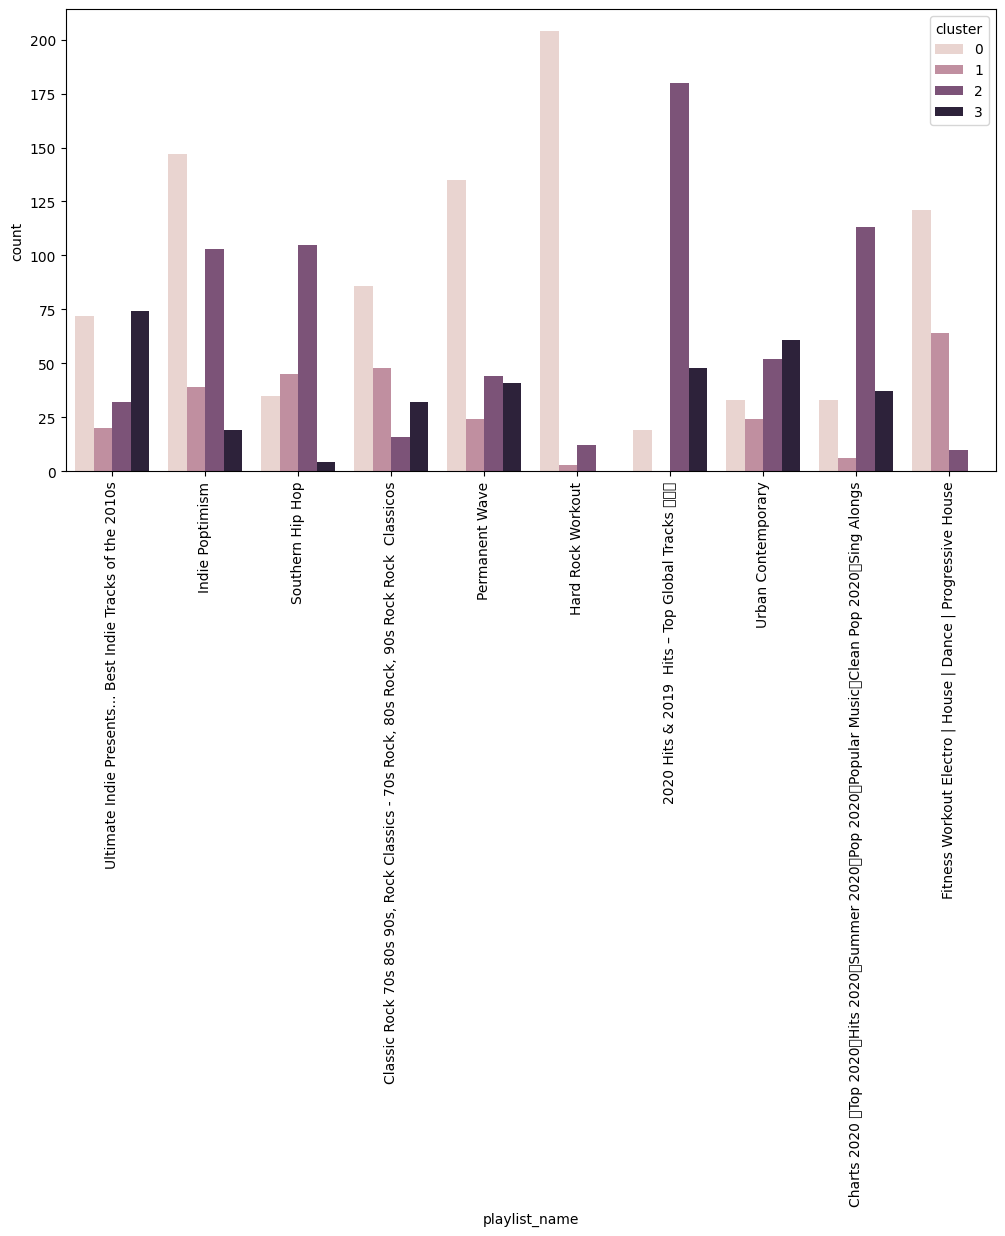

,track_name,playlist_genre
0,I Don't Care (with Justin Bieber) - Loud Luxur...,pop
1,Memories - Dillon Francis Remix,pop
2,All the Time - Don Diablo Remix,pop
4,Someone You Loved - Future Humans Remix,pop
5,Beautiful People (feat. Khalid) - Jack Wins Remix,pop
9,If I Can't Have You - Gryffin Remix,pop
10,Cross Me (feat. Chance the Rapper & PnB Rock) ...,pop
12,Body On My,pop
15,South of the Border (feat. Camila Cabello & Ca...,pop
17,Say My Name (feat. Bebe Rexha & J Balvin) - Lu...,pop


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from google.colab import files
#Load dataset
df = pd.read_csv("spotify data set.csv")
df.head()

#Data Preprocessing
df.info()
df.describe()
df.isnull().sum()
df = df.dropna()

features = df.select_dtypes(include=np.number)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

#Data Visualizations
df.hist(figsize=(12, 10))
plt.show()
sns.pairplot(df.select_dtypes(include=np.number).sample(200))
plt.show()

#Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(features.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#KMeans Clustering
WCSS= []

for i in range(1,11):
 kmeans = KMeans(n_clusters=i, random_state=42)
 kmeans.fit(scaled_features)
 WCSS.append(kmeans.inertia_)

plt.plot(range(1, 11), WCSS)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)


#Plot Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['danceability'], y=df['energy'], hue=df['cluster'], palette='viridis')
plt.title("Clusters of songs")
plt.show()


#Cluster by Playlist Genre
plt.figure(figsize=(10,6))
sns.countplot(x='playlist_genre', hue='cluster', data=df)
plt.xticks(rotation=45)
plt.title("Cluster vs Playlist Genre")
plt.show()


#Cluster by Playlist Name
top_playlists = df['playlist_name'].value_counts().head(10).index
filtered = df[df['playlist_name'].isin(top_playlists)]


plt.figure(figsize=(12,6))
sns.countplot(x='playlist_name', hue='cluster', data=filtered)
plt.xticks(rotation=90)
plt.show()


def recommend_songs(cluster_num):
 return df[df['cluster'] == cluster_num][['track_name', 'playlist_genre']].head(10)

recommend_songs(2)